In [ ]:
!pip install lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install lightning[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.3/224.3 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.4/624.4 kB 35.6 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import random
import torch.nn.functional as F

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving rl_dataset_ac_extended.csv to rl_dataset_ac_extended.csv


In [ ]:

#Dans ce notebook , on modélise par un réseau de neurones les réponses
#d'un circuit RL en régime AC ( en série , soumis à une tension sinusoidale).
"""But : prédire quatre grandeurs en sortie :
    - gain_bas : Gain mesuré aux basses fréquences (≈ comportement de la résistance)
    - gain_haut : Gain aux hautes fréquences (≈ comportement de l’inductance)
    - phase_V_R_rad : Phase de la tension aux bornes de R
    - phase_V_L_rad : Phase de la tension aux bornes de L

Formule physique du gain (module de la fonction de transfert) :
    |H(f)| = R / sqrt(R² + (2πfL)²)

À basse fréquence (f → 0), l’inductance L se comporte comme un fil (Z_L ≈ 0),
→ la tension est surtout sur R ⇒ gain_bas ≈ 1

À haute fréquence (f → ∞), l’inductance bloque le courant (Z_L → ∞),
→ la tension est surtout sur L ⇒ gain_haut ≈ 0

L’objectif est de faire apprendre ce comportement au réseau,
tout en le guidant avec une **perte physique** inspirée de la loi du gain théorique.
"""
#Dans ce code , on a un modèle avec 4 sorties à partir des entrées (R,L,frq..)

#Suivant cet structure :
#1 preparation des données , 2 . modele de regression , 3. entrainement du modele , 4. évalution , 5. visualisation des résultats
 # Initialise random seed for model weights and activations

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # If using torch.backends (optional for CPU, more relevant for CUDA)
    if torch.backends.mps.is_available():
        torch.use_deterministic_algorithms(True)

set_seed(42)
#chargement de la dataframe
df = pd.read_csv( "rl_dataset_ac_extended.csv" )
print( df.shape )

(1000000, 11)


In [ ]:
#1 preparation des données

#on definit un nombre s'échantillons à utiliser
test_size = 100000
#on selectionne 4 colonnes d'entrée , on prend les 100000 premieres lignes
X = df[["R", "L", "V_in", "Frequency_Hz"]].values[:test_size]
#Les sorties à prédire : V_R, V_L, I, Phase_R, Phase_L
# `I` et phases sont en radians
Y = df[["V_R", "V_L", "I_amplitude", "phase_V_R_rad", "phase_V_L_rad"]].values[:test_size]

#on crée les normalisations minmax pour les entrées X et les sorties Y :
#chaque valeur sera transformée poue être entre 0 et 1 .
#ça aide le réseau à converger plus rapidement
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_norm = scaler_x.fit_transform(X)
Y_norm = scaler_y.fit_transform(Y)
#Conversion des tableaux normalisés en tenseurs PyTorch avec float32 nécessaire pour le calcul du modèle .
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
Y_tensor = torch.tensor(Y_norm, dtype=torch.float32)
#on crée un dataset qui couple chaque entrée avec sa sortie associée
#Cela aide aussi à charger efficacement les données par batchs
dataset = TensorDataset(X_tensor, Y_tensor)
#la création d'un dataloader pour itérer sur les données d'enrainement .
#ils seront chargées en mini-lots de 256 et le shuffle true va permettre d'eviter
#le surapprentissage sur l'ordre des données
loader = DataLoader(dataset, batch_size=256, shuffle=True)
#pour le choix automatique entre GPU et CPU .
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 3. Model definition
#privilege d'une architecture avec profondeur moyenne et largeur elevée
# 4 couches cachées et beaucoup de neurones par couche .
#f(R,L,Vin,frq) -> (VR, VL,I)
#nombre de neurones par couche.
nb_neu = 256
#Activation tanh : ce choix permet de mieux capturer les non-linéarités
# la sortie avec sigmoid puisque on a normalisé avec minmax
class RegressionModel(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, nb_neu)
        self.fc2 = nn.Linear(nb_neu, nb_neu)
        self.fc3 = nn.Linear(nb_neu, nb_neu)
        self.fc4 = nn.Linear(nb_neu, nb_neu)
        self.fc5 = nn.Linear(nb_neu, out_features)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        x = torch.tanh(self.fc4(x))
        return torch.sigmoid(self.fc5(x))

#X_tensor.shape[1] donne les données d'entrée et [1] donne celles de sortie
#to(device) : on alterne  sur le CPU si disponible .
model = RegressionModel(X_tensor.shape[1], Y_tensor.shape[1]).to(device)
#################################################################################
#Le problème est : les sorties ont des echelles différentes ce qui crée des niveaux
#de bruit différents .
#Paramètres de pondération pour le multitask loss
#Chaque sortie aura une pondértion dynamiquement apprise .
# pour plus de stabilité numérique on utilise les log-variances .
log_vars = nn.Parameter(torch.zeros(Y_tensor.shape[1]), requires_grad=True)

def multitask_loss(Y_pred, Y_true):
        # plus il y'a des incertitudes sur la tache  moins elle est pénalisée .
        #plus elle est précise plus elle influence d'apprentissage .
        #puis le rajout de log_variance est une régularisation
        loss = 0
        for i in range(Y_true.shape[1]):
            precision = torch.exp(-log_vars[i])
            loss += precision * F.mse_loss(Y_pred[:, i], Y_true[:, i]) + log_vars[i]
        return loss

    #optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#on entraine à la fois les poids du modele et les log-var pour adapter dynamiquement
optimizer = torch.optim.Adam(list(model.parameters()) + [log_vars], lr=1e-3)
#quand la perte stagne , on réduit le learning rate via ReduceLROnPlateau
#factor=0.5 on divise le lr par deux , la patience ( aucune amélioration sur 50epochs)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=50, verbose=True)



/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
# 4. Physical loss for RL AC

def physical_loss_rl_ac(X_scaled, Y_pred_scaled, scaler_x):
    # Denormalisation
    #inverse transform va assurer la remise des variables dans leurs unités physiques
      X_np = scaler_x.inverse_transform(X_scaled.cpu().numpy())
      f = torch.tensor(X_np[:,3], dtype=torch.float32)
      R = torch.tensor(X_np[:,0], dtype=torch.float32)
      L = torch.tensor(X_np[:,1], dtype=torch.float32)
      Gr_pred = Y_pred_scaled[:,0]  # gain_bas
      Gl_pred = Y_pred_scaled[:,1]  # gain_haut
      #les contraintes physiques
      # w= 2πf
      omega = 2 * torch.pi * f
      Gr_theo = R / torch.sqrt(R**2 + (omega*L)**2)
      Gl_theo = (omega*L) / torch.sqrt(R**2 + (omega*L)**2)
      #on compare les valeurs prédites avec les valeurs théoriques
      return F.mse_loss(Gr_pred, Gr_theo) + F.mse_loss(Gl_pred, Gl_theo)
      # Paramètres log_vars à apprendre automatiquement

In [ ]:
n_epochs = 201
#ce coefficient pondère l'importance de la contrainte physique
lambda_phys = 1e-3
#pour tracer l'historique des pertes et du taux d'apprentissage
history = {"epoch": [], "data_loss": [], "phys_loss": [], "lr": []}
for epoch in range(n_epochs):
    total_data = total_phys = 0.0
    #boucle sur les données
    for Xb, Yb in loader:
      #on passe sur GPU si  disponible
        Xb, Yb = Xb.to(device), Yb.to(device)

        # → Forward passs
        #prédiction du modèle
        Yp = model(Xb)
        #loss de régression
        ld = F.mse_loss(Yp, Yb)
        #perte physique
        lp = physical_loss_rl_ac(Xb, Yp, scaler_x)
        #perte totale pondérée
        loss = ld + lambda_phys * lp

        # → Backward avec gradient clipping
        #rétropopagation et optimisation
        optimizer.zero_grad()
        loss.backward()
        #empeche les gradients explosifs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_data += ld.item()
        total_phys += lp.item()


    # Moyenne de la perte supervisée
    #avg_data = total_data / len(loader)
    # Moyenne de la perte physique
    avg_data = total_data / len(loader)
    avg_phys = total_phys / len(loader)
    #Ajustement dynamique du LR selon la perte totale
    scheduler.step(avg_data + lambda_phys * avg_phys)


    # Logging lissé
    if epoch % 10 == 0:
        avg_phys = total_phys / len(loader)
        print(f"Epoch {epoch} | Data Loss: {avg_data:.4f} | Phys Loss: {avg_phys:.4f}")


Epoch 0 | Data Loss: 0.1048 | Phys Loss: 0.2320
Epoch 10 | Data Loss: 0.0548 | Phys Loss: 0.1234
Epoch 20 | Data Loss: 0.0443 | Phys Loss: 0.0999
Epoch 30 | Data Loss: 0.0369 | Phys Loss: 0.0836
Epoch 40 | Data Loss: 0.0329 | Phys Loss: 0.0747
Epoch 50 | Data Loss: 0.0288 | Phys Loss: 0.0656
Epoch 60 | Data Loss: 0.0267 | Phys Loss: 0.0610
Epoch 70 | Data Loss: 0.0231 | Phys Loss: 0.0528
Epoch 80 | Data Loss: 0.0220 | Phys Loss: 0.0502
Epoch 90 | Data Loss: 0.0216 | Phys Loss: 0.0494
Epoch 100 | Data Loss: 0.0197 | Phys Loss: 0.0450
Epoch 110 | Data Loss: 0.0194 | Phys Loss: 0.0445
Epoch 120 | Data Loss: 0.0188 | Phys Loss: 0.0431
Epoch 130 | Data Loss: 0.0168 | Phys Loss: 0.0384
Epoch 140 | Data Loss: 0.0168 | Phys Loss: 0.0386
Epoch 150 | Data Loss: 0.0174 | Phys Loss: 0.0397
Epoch 160 | Data Loss: 0.0165 | Phys Loss: 0.0378
Epoch 170 | Data Loss: 0.0163 | Phys Loss: 0.0374
Epoch 180 | Data Loss: 0.0140 | Phys Loss: 0.0323
Epoch 190 | Data Loss: 0.0146 | Phys Loss: 0.0335
Epoch 200 |

Epoch   0 | Data Loss: 6.6700e-04 | Phys Loss: 2.2338e-02 | Total: 6.8934e-04 | LR: 5.00e-04
Epoch  10 | Data Loss: 8.7095e-04 | Phys Loss: 4.2533e-02 | Total: 9.1348e-04 | LR: 5.00e-04
Epoch  20 | Data Loss: 9.3302e-04 | Phys Loss: 5.8624e-02 | Total: 9.9165e-04 | LR: 5.00e-04
Epoch  30 | Data Loss: 9.7796e-04 | Phys Loss: 8.4327e-02 | Total: 1.0623e-03 | LR: 5.00e-04
Epoch  40 | Data Loss: 9.6658e-04 | Phys Loss: 7.8817e-02 | Total: 1.0454e-03 | LR: 5.00e-04
Epoch  50 | Data Loss: 9.5709e-04 | Phys Loss: 7.4744e-02 | Total: 1.0318e-03 | LR: 5.00e-04
Epoch  60 | Data Loss: 7.9136e-04 | Phys Loss: 3.3552e-02 | Total: 8.2491e-04 | LR: 2.50e-04
Epoch  70 | Data Loss: 7.5954e-04 | Phys Loss: 2.7338e-02 | Total: 7.8688e-04 | LR: 2.50e-04
Epoch  80 | Data Loss: 6.4230e-04 | Phys Loss: 1.5985e-02 | Total: 6.5829e-04 | LR: 2.50e-04
Epoch  90 | Data Loss: 7.0983e-04 | Phys Loss: 2.1401e-02 | Total: 7.3123e-04 | LR: 2.50e-04
Epoch 100 | Data Loss: 6.3720e-04 | Phys Loss: 1.6033e-02 | Total: 6.5

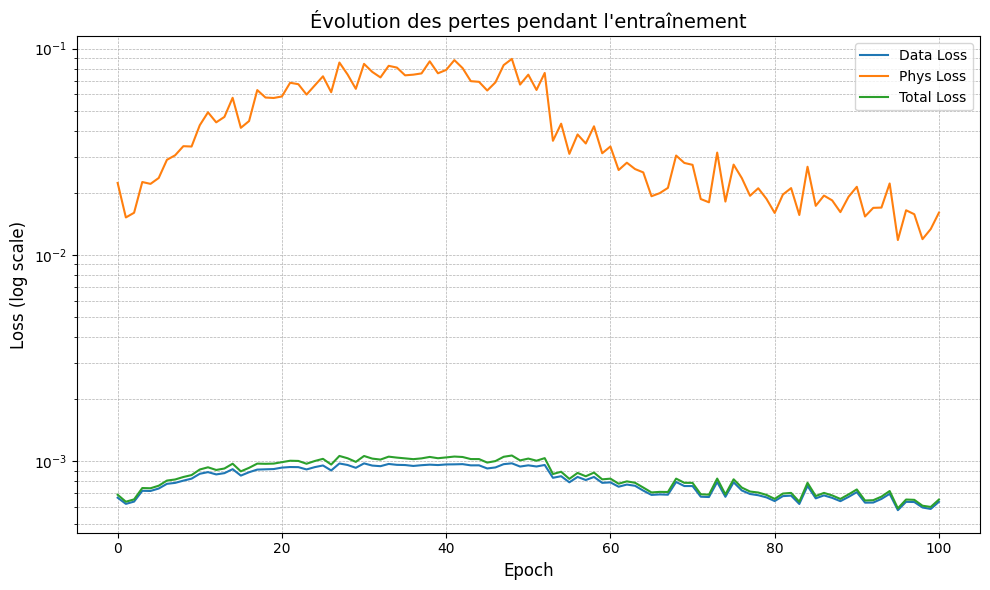

In [ ]:
import matplotlib.pyplot as plt

n_epochs = 101
lambda_phys = 1e-3
alpha = 1.0  # pondération de la data_loss
history = {"epoch": [], "data_loss": [], "phys_loss": [], "total_loss": [], "lr": []}

for epoch in range(n_epochs):
    total_data = 0.0
    total_phys = 0.0

    for Xb, Yb in loader:
        Xb, Yb = Xb.to(device), Yb.to(device)

        # --- Pondération dynamique par fréquence ---
        #chaque echatillon dans le batch reçoit un poids inversement proportionnel à sa frq
        #cela favorise l 'apprentissage en basse frq
        freq_batch = scaler_x.inverse_transform(Xb.cpu())[:, 3]
        weights = 1 / (freq_batch + 1e-3)
        weights = weights / weights.max()  # normalisation optionnelle
        weights = torch.tensor(weights, dtype=torch.float32).to(device)

        Yp = model(Xb)

        # Calcul MSE par échantillon puis on fait une moy pondérée avec les poids
        loss_per_sample = (Yp - Yb) ** 2
        loss_per_sample = loss_per_sample.mean(dim=1)  # MSE par échantillon
        ld = (loss_per_sample * weights).mean()        # perte pondérée
        #C’est un rééchantillonnage pondéré implicite.

        lp = physical_loss_rl_ac(Xb, Yp, scaler_x)
        loss = alpha * ld + lambda_phys * lp

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_data += ld.item()
        total_phys += lp.item()

    avg_data = total_data / len(loader)
    avg_phys = total_phys / len(loader)
    total_loss = alpha * avg_data + lambda_phys * avg_phys

    scheduler.step(total_loss)

    # Enregistrement historique
    history["epoch"].append(epoch)
    history["data_loss"].append(avg_data)
    history["phys_loss"].append(avg_phys)
    history["total_loss"].append(total_loss)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    # Affichage
    if epoch % 10 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:3d} | Data Loss: {avg_data:.4e} | Phys Loss: {avg_phys:.4e} | Total: {total_loss:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# Courbes de loss (log scale)
plt.figure(figsize=(10, 6))
plt.plot(history["epoch"], history["data_loss"], label="Data Loss")
plt.plot(history["epoch"], history["phys_loss"], label="Phys Loss")
plt.plot(history["epoch"], history["total_loss"], label="Total Loss")
plt.yscale("log")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (log scale)", fontsize=12)
plt.title("Évolution des pertes pendant l'entraînement", fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
n_epochs = 201
lambda_phys = 1e-3
history = {"epoch": [], "data_loss": [], "phys_loss": [], "lr": []}
for epoch in range(n_epochs):
    total_data = 0.0
    total_phys = 0.0

    for Xb, Yb in loader:
        Xb, Yb = Xb.to(device), Yb.to(device)

        Yp = model(Xb)
        ld = F.mse_loss(Yp, Yb)
        lp = physical_loss_rl_ac(Xb, Yp, scaler_x)
        loss = ld + lambda_phys * lp

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_data += ld.item()
        total_phys += lp.item()

    avg_data = total_data / len(loader)
    avg_phys = total_phys / len(loader)

    # Scheduler step: ici, à la fin de l'epoch, sur la perte totale moyenne
    scheduler.step(avg_data + lambda_phys * avg_phys)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Data Loss: {avg_data:.4f} | Phys Loss: {avg_phys:.4f}")


Epoch 0 | Data Loss: 0.0079 | Phys Loss: 0.0185
Epoch 10 | Data Loss: 0.0082 | Phys Loss: 0.0191
Epoch 20 | Data Loss: 0.0070 | Phys Loss: 0.0162
Epoch 30 | Data Loss: 0.0070 | Phys Loss: 0.0161
Epoch 40 | Data Loss: 0.0077 | Phys Loss: 0.0179
Epoch 50 | Data Loss: 0.0064 | Phys Loss: 0.0150
Epoch 60 | Data Loss: 0.0068 | Phys Loss: 0.0159
Epoch 70 | Data Loss: 0.0065 | Phys Loss: 0.0152
Epoch 80 | Data Loss: 0.0071 | Phys Loss: 0.0165
Epoch 90 | Data Loss: 0.0064 | Phys Loss: 0.0149
Epoch 100 | Data Loss: 0.0052 | Phys Loss: 0.0121
Epoch 110 | Data Loss: 0.0061 | Phys Loss: 0.0143
Epoch 120 | Data Loss: 0.0066 | Phys Loss: 0.0153
Epoch 130 | Data Loss: 0.0054 | Phys Loss: 0.0127
Epoch 140 | Data Loss: 0.0065 | Phys Loss: 0.0151
Epoch 150 | Data Loss: 0.0063 | Phys Loss: 0.0147
Epoch 160 | Data Loss: 0.0042 | Phys Loss: 0.0098
Epoch 170 | Data Loss: 0.0033 | Phys Loss: 0.0079
Epoch 180 | Data Loss: 0.0037 | Phys Loss: 0.0087
Epoch 190 | Data Loss: 0.0037 | Phys Loss: 0.0087
Epoch 200 |

Validation MSE Loss: 0.0181


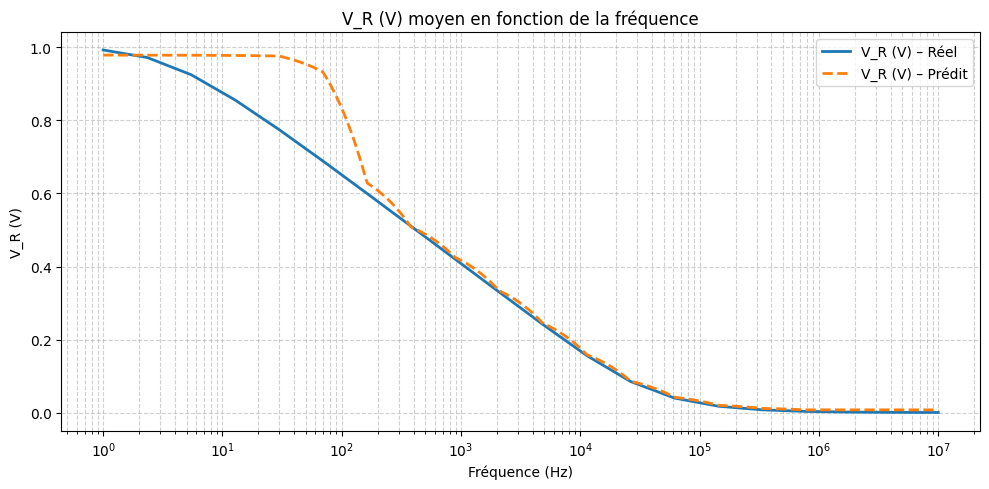

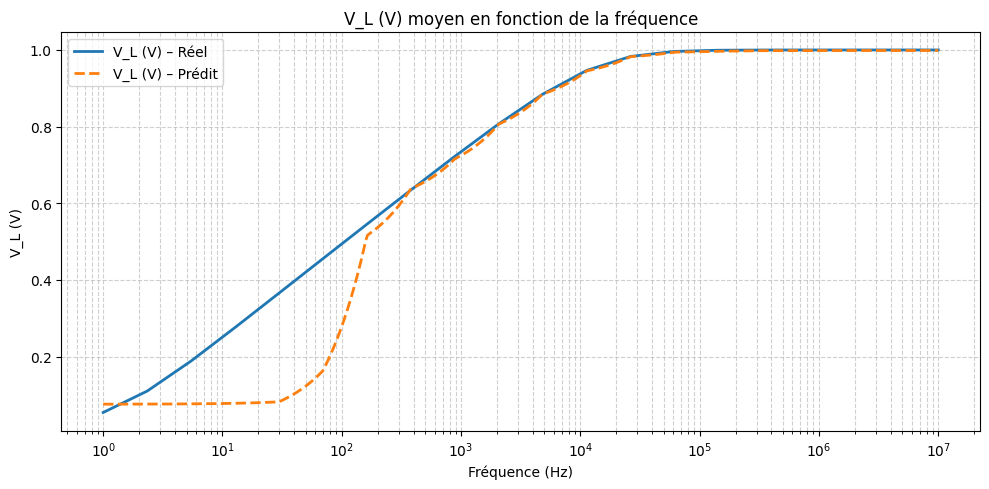

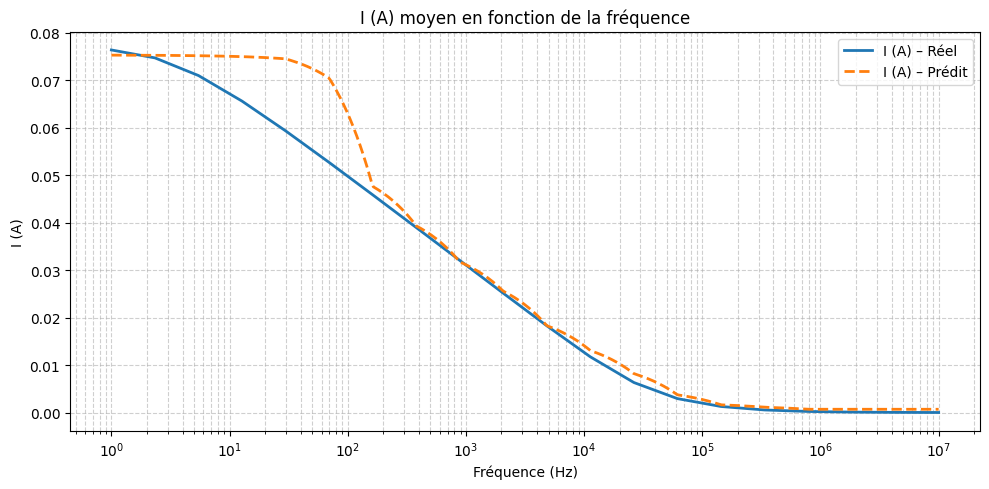

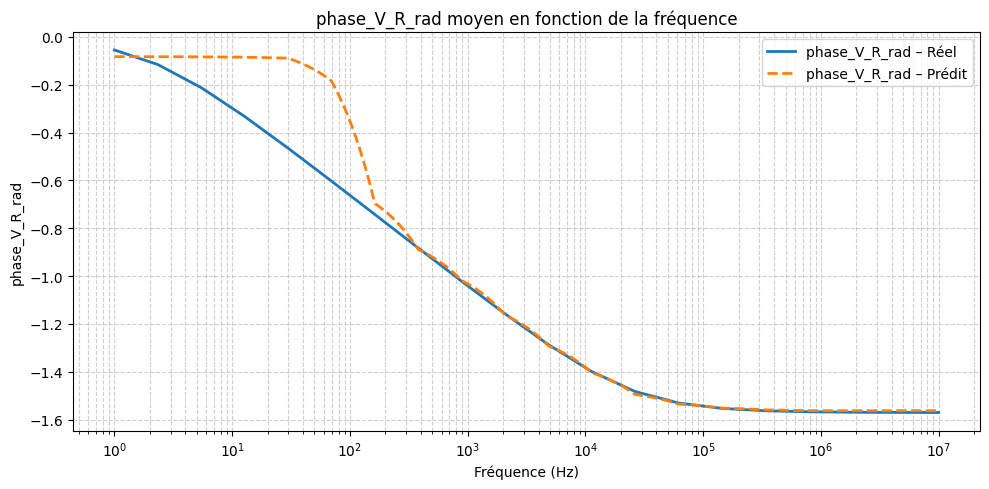

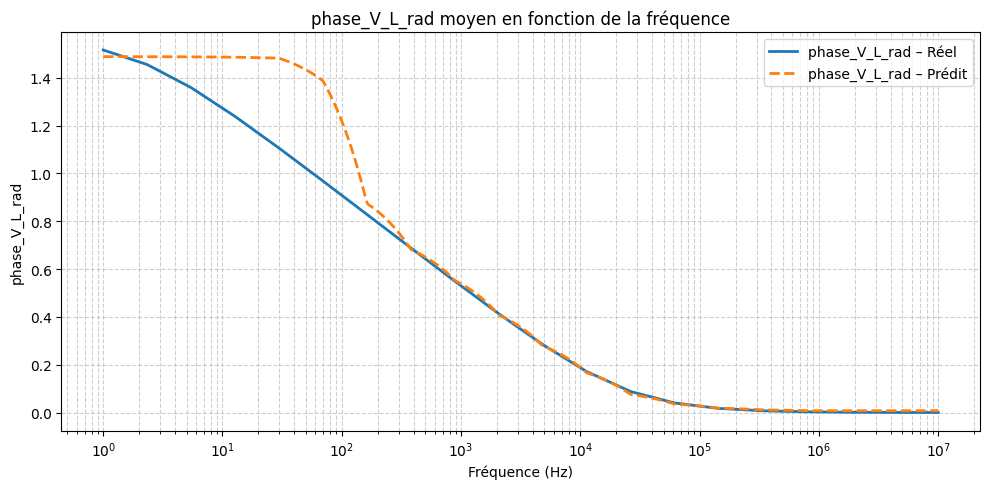

In [ ]:
# 6. Evaluation
#######################
#meilleur plot
#######################
model.eval()
#on désactive le gradient pour prédire sur l'ensemble d'evaluation puis on recalcule le MSE
with torch.no_grad():
    Y_pred_norm = model(X_tensor.to(device)).cpu()
    val_loss = F.mse_loss(Y_pred_norm, Y_tensor)
    print(f"Validation MSE Loss: {val_loss.item():.4f}")

#on récupère les vraies valeurs de tension ,phase et les fréquences
Y_pred_denorm = scaler_y.inverse_transform(Y_pred_norm.numpy())
Y_true_denorm = scaler_y.inverse_transform(Y_tensor.numpy())
frequencies = scaler_x.inverse_transform(X_tensor.numpy())[:, 3]

labels = ["V_R (V)", "V_L (V)", "I (A)", "phase_V_R_rad", "phase_V_L_rad"]

for i in range(Y_true_denorm.shape[1]):
    df_plot = pd.DataFrame({
        "Frequency": frequencies,
        "True": Y_true_denorm[:, i],
        "Pred": Y_pred_denorm[:, i]
    })
    df_mean = df_plot.groupby("Frequency").mean().reset_index()

    plt.figure(figsize=(10, 5))
    #from scipy.interpolate import make_interp_spline  # Assure-toi que c'est bien importé

# Ajoute ces lignes avant les plt.semilogx(...)
    #freq_smooth = np.logspace(np.log10(df_mean["Frequency"].min()), np.log10(df_mean["Frequency"].max()), 500)
    #spline_pred = make_interp_spline(df_mean["Frequency"], df_mean["Pred"])
    #plt.semilogx(df_mean["Frequency"], df_mean["True"], label=f"{labels[i]} – Réel", linewidth=2)
    #plt.semilogx(df_mean["Frequency"], df_mean["Pred"], label=f"{labels[i]} – Prédit",
                # linestyle="--", linewidth=2)
   # plt.semilogx(freq_smooth, spline_pred(freq_smooth), label=f"{labels[i]} – Prédit", linestyle="--", linewidth=2)
    from scipy.interpolate import interp1d  # ← ✅ à importer au début du script

    # Ajoute ce bloc à la place du précédent :
    df_mean = df_mean.sort_values(by="Frequency")  # 🔒 sécurité pour l'interpolation
    freq = df_mean["Frequency"].values
    y_true = df_mean["True"].values
    y_pred = df_mean["Pred"].values

    freq_smooth = np.logspace(np.log10(freq.min()), np.log10(freq.max()), 500)
    interp_pred = interp1d(freq, y_pred, kind='linear', fill_value='extrapolate')

    plt.semilogx(freq, y_true, label=f"{labels[i]} – Réel", linewidth=2)
    plt.semilogx(freq_smooth, interp_pred(freq_smooth), label=f"{labels[i]} – Prédit", linestyle="--", linewidth=2)

    plt.xlabel("Fréquence (Hz)")
    plt.ylabel(labels[i])
    plt.title(f"{labels[i]} moyen en fonction de la fréquence")
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


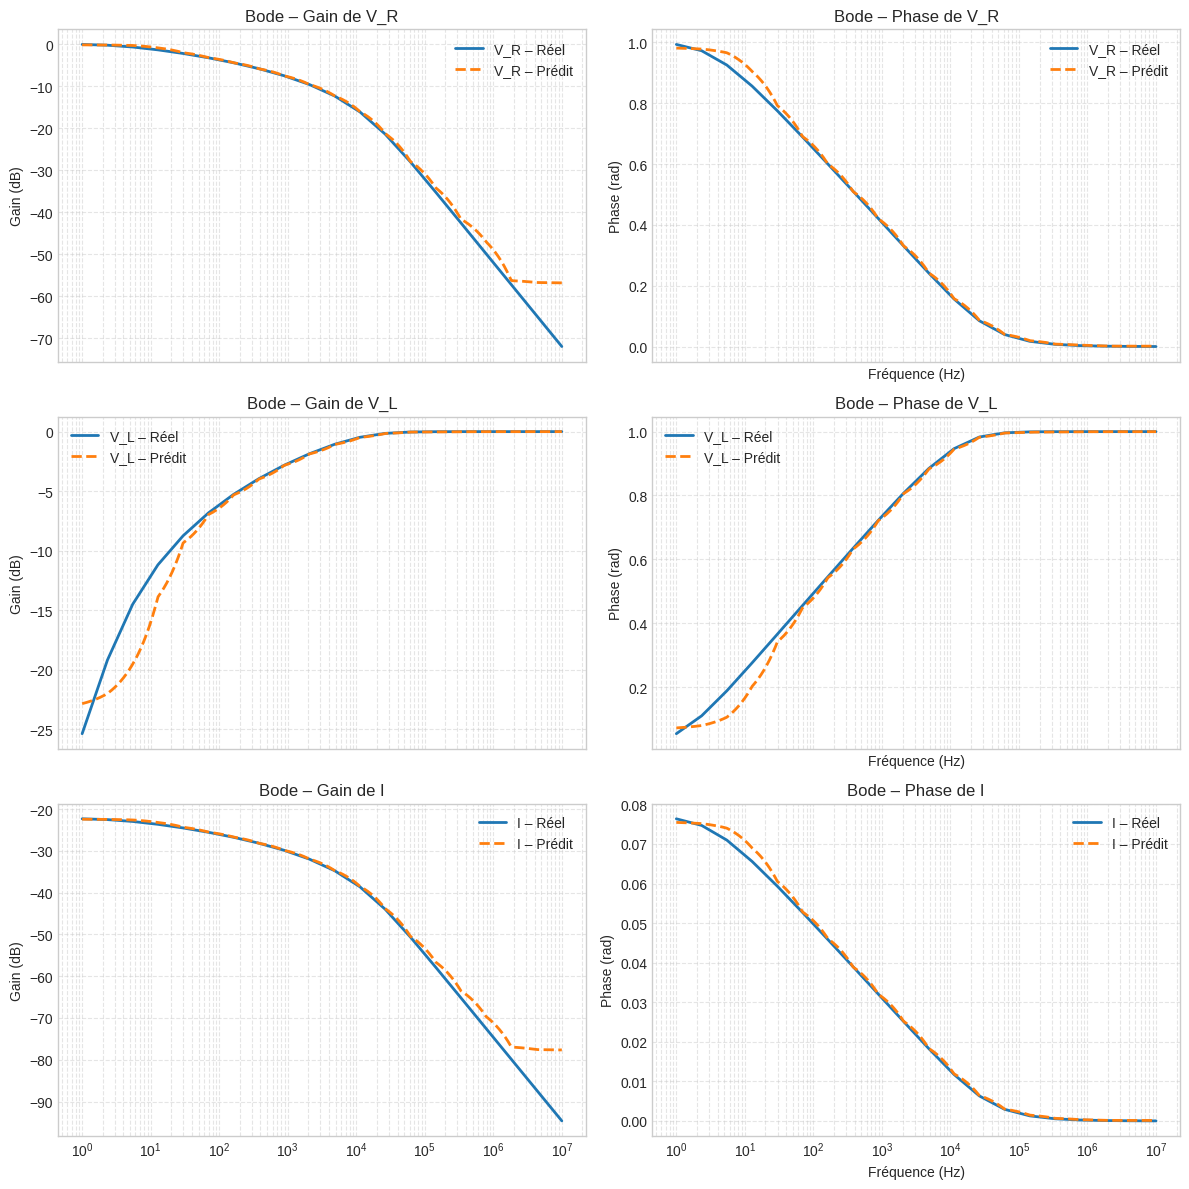

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
"""Les étapes principales sont :
- Regrouper les valeurs réelles et prédites par fréquence et calculer la moyenne (pour lisser les mesures).
- Appliquer une interpolation linéaire pour lisser visuellement les courbes prédites.
- Tracer les courbes en échelle semi-logarithmique pour la fréquence (axe x).
- Séparer les sous-graphiques par grandeur physique pour une lecture plus claire."""


# 1) Définition de la fonction de tracé Bode
def plot_bode_from_df(df_mean, label, ax_gain, ax_phase):
    freq = df_mean["Frequency"].values
    y_true = df_mean["True"].values
    y_pred = df_mean["Pred"].values

    # Gain en dB
    #
    gain_true = 20 * np.log10(np.abs(y_true))
    gain_pred = 20 * np.log10(np.abs(y_pred))
    freq_smooth = np.logspace(np.log10(freq.min()), np.log10(freq.max()), 500)
    interp_gain = interp1d(freq, gain_pred, kind='linear', fill_value='extrapolate')
    gain_pred_smooth = interp_gain(freq_smooth)

    ax_gain.semilogx(freq, gain_true,    label=f"{label} – Réel", linewidth=2)
    ax_gain.semilogx(freq_smooth, gain_pred_smooth, '--', label=f"{label} – Prédit", linewidth=2)
    ax_gain.set_ylabel("Gain (dB)")
    ax_gain.set_title(f"Bode – Gain de {label}")
    ax_gain.grid(True, which="both", linestyle="--", alpha=0.5)
    ax_gain.legend()

    # Phase en radians
    interp_phase = interp1d(freq, y_pred, kind='linear', fill_value='extrapolate')
    phase_pred_smooth = interp_phase(freq_smooth)

    ax_phase.semilogx(freq, y_true,    label=f"{label} – Réel", linewidth=2)
    ax_phase.semilogx(freq_smooth, phase_pred_smooth, '--', label=f"{label} – Prédit", linewidth=2)
    ax_phase.set_ylabel("Phase (rad)")
    ax_phase.set_xlabel("Fréquence (Hz)")
    ax_phase.set_title(f"Bode – Phase de {label}")
    ax_phase.grid(True, which="both", linestyle="--", alpha=0.5)
    ax_phase.legend()


# 2) Prépare tes données : df_mean pour V_R, V_L, I
#    (ici j'utilise tes arrays Y_true_denorm, Y_pred_denorm et frequencies)
labels = ["V_R", "V_L", "I"]
n_signals = len(labels)

fig, axes = plt.subplots(n_signals, 2, figsize=(12, 4*n_signals), sharex=True)

for idx, label in enumerate(labels):
    # Construit le DataFrame groupé par fréquence
    df_plot = pd.DataFrame({
        "Frequency": frequencies,
        "True": Y_true_denorm[:, idx],
        "Pred": Y_pred_denorm[:, idx]
    })
    df_mean = df_plot.groupby("Frequency").mean().reset_index()
    df_mean = df_mean.sort_values("Frequency")  # obligatoire pour interp1d

    ax_gain  = axes[idx, 0]
    ax_phase = axes[idx, 1]
    plot_bode_from_df(df_mean, label, ax_gain, ax_phase)

# 3) Ajustements finaux et affichage
plt.tight_layout()
plt.show()
